In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('../Iris.csv')

X = df.drop(columns=['Species']).values
y_true = LabelEncoder().fit_transform(df['Species'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [3]:
# inertias = []
# K_range = range(1, 11)

# for k in K_range:
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     km.fit(X_scaled)
#     inertias.append(km.inertia_)

# plt.figure(figsize=(7, 4))
# plt.plot(K_range, inertias, marker='o', linestyle='--', color='b')
# plt.title('Elbow Method for Optimal k')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia (WCSS)')
# plt.xticks(K_range)
# plt.grid(True, linestyle=':', alpha=0.6)
# plt.show()

In [4]:
agglo = AgglomerativeClustering(n_clusters=3)
y_agglo = agglo.fit_predict(X_scaled)

print("\n--- CLUSTERING METRICS ---")
print(f"Agglomerative Silhouette Score:  {silhouette_score(X_scaled, y_agglo):.4f}")


--- CLUSTERING METRICS ---
Agglomerative Silhouette Score:  0.4518


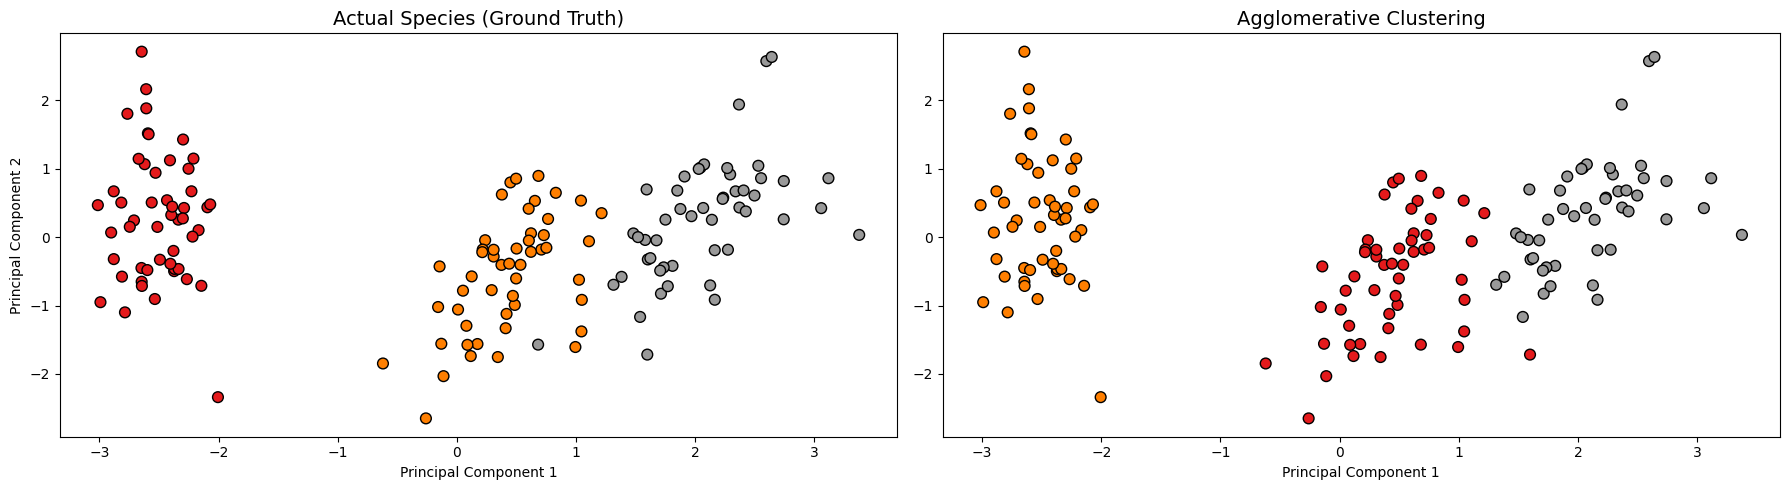

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Visualize Actual Ground Truth
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='Set1', s=60, edgecolor='k')
axes[0].set_title('Actual Species (Ground Truth)', fontsize=14)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# 2. Visualize Agglomerative Clustering
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_agglo, cmap='Set1', s=60, edgecolor='k')
axes[1].set_title('Agglomerative Clustering', fontsize=14)
axes[1].set_xlabel('Principal Component 1')

plt.tight_layout()
plt.show()